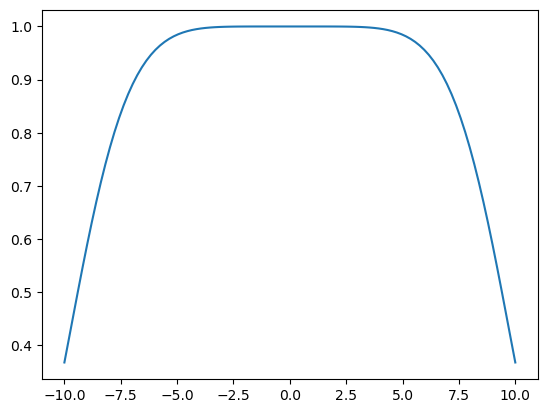

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# gaussian parameters
n = 6  # order of the Gaussian
A = 1  # amplitude

x = np.linspace(-10, 10, 100)
y = A * np.exp(-((x - 0)/10)**n)




plt.plot(x, y, label=f'Gaussian (n={n})')
# plt.yscale('log')

In [2]:
np.finfo(float).eps


2.220446049250313e-16

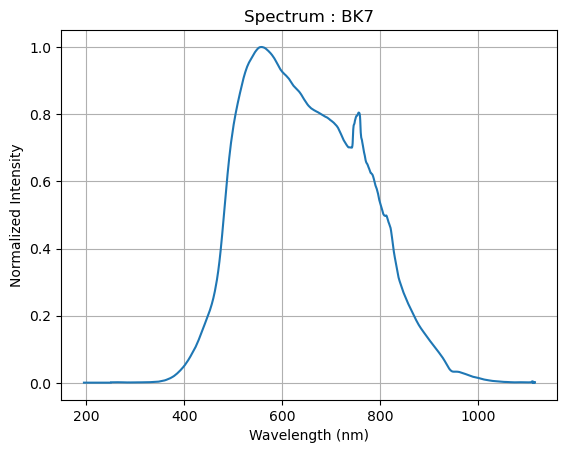

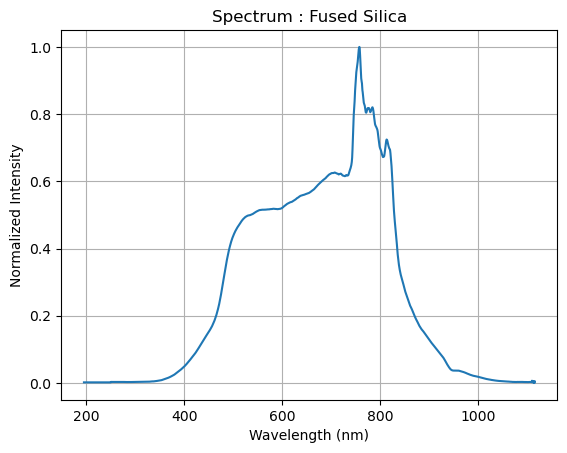

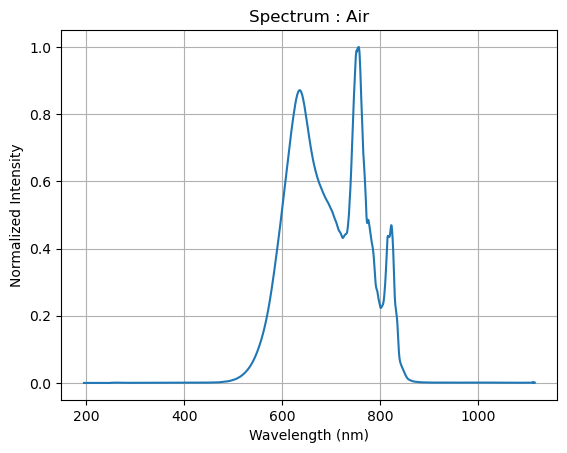

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import ifft, fftshift, fftfreq
from scipy.interpolate import interp1d
from sklearn.preprocessing import MinMaxScaler



def plot_from_csv(file_path, title):
    df = pd.read_csv(file_path)
    df.columns = ['Wavelength(nm)', 'Intensity']
    
    # Normalize intensity between 0 and 1
    x_nm = df['Wavelength(nm)'].values
    y = df['Intensity'].values
    y = MinMaxScaler().fit_transform(y.reshape(-1, 1)).flatten()
    
    plt.plot(x_nm, y)
    plt.title(f"Spectrum : {title}")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Normalized Intensity")
    plt.grid()
    plt.show()


plot_from_csv("mean_bk7_spectrum.csv", "BK7")
plot_from_csv("mean_fs_spectrum.csv", "Fused Silica")
plot_from_csv("mean_air_spectrum.csv", "Air")

In [4]:
import csv

from nbformat import convert

def convert_txt_to_csv(txt_file_path, csv_file_path, delimiter=None):
    """
    Converts a TXT file with two columns into a CSV file with headers 'Wavelength' and 'Intensity'.
    
    :param txt_file_path: Path to the input TXT file
    :param csv_file_path: Path to the output CSV file
    :param delimiter: Delimiter used in the TXT file (default is any whitespace)
    """
    with open(txt_file_path, 'r') as txt_file:
        lines = txt_file.readlines()

    data = []
    for line in lines:
        if line.strip():  # skip empty lines
            parts = line.strip().split(delimiter)
            if len(parts) >= 2:
                wavelength, intensity = parts[0], parts[1]
                data.append([wavelength, intensity])

    with open(csv_file_path, 'w', newline='') as csv_file:
        writer = csv.writer(csv_file)
        writer.writerow(['Wavelength(nm)', 'Intensity'])  # header
        writer.writerows(data)

    print(f"Conversion completed. CSV saved at: {csv_file_path}")
    
convert_txt_to_csv("amplifier_spectrum.txt", "amplifier_spectrum.csv")


Conversion completed. CSV saved at: amplifier_spectrum.csv
